# PR06 · Labels, posterior probabilities and partial volume are different

<!-- paper-first -->
### Begin with the paper question

**Read or revisit [PP03](../../curriculum/papers/processing.md#pp03).** Use the assigned first-pass sections in the guide; if you already read them, return only to the relevant figure or claim. Do this before the technical explanation below.

**Motivation:** What is lost when a probability or a mixed-tissue voxel becomes one categorical label?

Write a two-sentence prediction and one thing you cannot yet explain. Ask your AI tutor to locate evidence in the supplied paper and distinguish it from inference. A paper link motivates this question; it does not mean the paper uses every method demonstrated here.

**After the experiment:** revisit your prediction in the [evidence ledger](../../curriculum/coursework/EVIDENCE_LEDGER.md). Explain one mechanism you now understand, cite a result from this notebook, and name a paper claim this exercise still cannot test. Keep a small demonstration distinct from a reproduction of the study.
<!-- /paper-first -->

**Format:** 75–100 minutes for this lesson and its small executable lab, followed by the explicitly labeled upstream practice. Run this notebook from a fresh kernel, top to bottom. Core data are synthetic. Software: NumPy, SciPy, Matplotlib; extra imports are stated in code. This is one stage of a longer processing course, not a replacement for supervised research training.

## Learning objectives

- Read a mixture-model assignment without inventing anatomical certainty.
- Distinguish classification probability from tissue fraction.
- Evaluate bias sensitivity and downstream volume implications.

## Understand the operation

Tissue segmentation attempts to distinguish classes such as gray matter, white matter and CSF using measured contrast and often spatial information or prior anatomy. Classes are model outputs, not microscopic ground truth. Intensity distributions can overlap; bias fields, noise, pathology and partial volume complicate the assignment. The meaning and order of label IDs are software conventions that must be verified.

A posterior probability describes uncertainty about a class under a model. A partial-volume estimate describes how much of a voxel is occupied by a tissue under a mixing model. These concepts can coincide in special simplified cases, but they are not generally interchangeable. A voxel whose noisy intensity leaves us uncertain between pure tissues is different from a voxel containing both tissues. Summing class posteriors gives an expected count under that classification model; it is not automatically a validated fractional tissue-volume estimate.

We fit a two-component Gaussian mixture to synthetic pure-tissue intensities. Component indices can permute, so we identify the higher-mean component explicitly rather than naming component zero “white matter.” We then compare a classifier posterior for an intermediate observation with the fraction in a known linear mixing equation. The latter uses known endmembers and has its own strong assumptions. Real segmentation tools jointly address spatial constraints, bias and partial volume in tool-specific ways. Inspect boundaries and class maps separately, especially near ventricles, cortical edges and abnormal tissue.

## Transformation contract

**Input:** observed voxel intensities. **Output:** mixture parameters, posterior matrix and hard labels. **Preserved:** the original intensities only if retained separately. **Lost through argmax:** uncertainty. **Distinct extra model:** known two-endmember mixture converts intensity to a fraction; it is not the fitted Gaussian posterior.


## Read the actual course material

- [Oxford FSL: Structural Analysis practical](https://pages.fmrib.ox.ac.uk/fslcourse/practicals/seg_struc/index.html). Public university practical; linked only.

Read the named topic alongside this lesson; compare its real-image assumptions with our controlled example. These notebooks use original explanations and original code, not copied upstream passages. The source chapter is the place to continue to a complete real-tool practical. External software and downloaded datasets are not silently run by this notebook.


## Predict, then ask your AI assistant

Use Goose with your installed Ollama model, or ChatGPT. The model is a tutor and code author; the local Python runtime performs these calculations. Paste:

> Fit the two-component mixture, then identify the higher-mean component from its learned mean. Compare its posterior at intensity75 with a separately defined linear tissue fraction. Explain why both numbers can be valid under different assumptions. Return at most 20 executable lines per cell, show units and array shapes, and preserve the original. Explain the prediction before running. If an assertion fails, diagnose the disagreement rather than deleting the check.

Write your prediction before executing the reference cells below.


In [1]:
import numpy as np
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt
rng=np.random.default_rng(6006)
intensity=np.r_[rng.normal(60,5,500),rng.normal(100,5,500)][:,None]
true_class=np.r_[np.zeros(500,dtype=int),np.ones(500,dtype=int)]
gmm=GaussianMixture(2,random_state=6).fit(intensity)
wm_component=int(np.argmax(gmm.means_.ravel()))
post=gmm.predict_proba(intensity)[:,wm_component]
labels=(post>.5).astype(int)
print('component means:',gmm.means_.ravel(),'classification accuracy:',np.mean(labels==true_class))
assert np.mean(labels==true_class)>.98
assert np.allclose(gmm.predict_proba(intensity).sum(1),1)


component means: [100.15604011  60.02876311] classification accuracy: 1.0


high-mean class posterior / known mixing fraction: 0.00020734781228702338 0.375


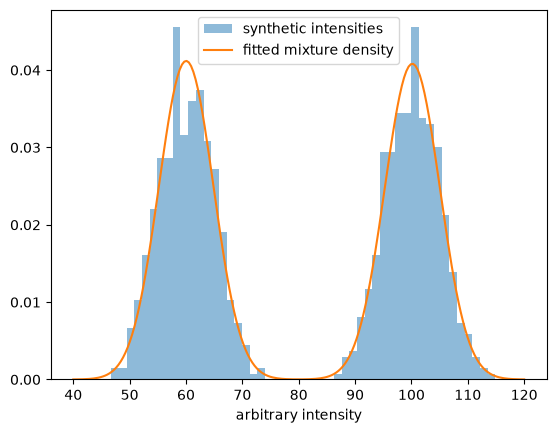

In [2]:
test_value=75.
posterior=float(gmm.predict_proba([[test_value]])[0,wm_component])
fraction=(test_value-60)/(100-60)
print('high-mean class posterior / known mixing fraction:',posterior,fraction)
assert abs(posterior-fraction)>.1 and fraction==.375
biased=intensity*.75
biased_labels=(gmm.predict_proba(biased)[:,wm_component]>.5).astype(int)
assert np.mean(biased_labels==true_class)<np.mean(labels==true_class)
grid=np.linspace(40,120,200)
plt.hist(intensity.ravel(),bins=50,density=True,alpha=.5,label='synthetic intensities')
plt.plot(grid,np.exp(gmm.score_samples(grid[:,None])),label='fitted mixture density')
plt.xlabel('arbitrary intensity'); plt.legend(); plt.show()


## Check and explain

Class-posterior rows sum to one and clean pure-tissue classification exceeds98%. At75, the linear fraction is .375 while the classification posterior is substantially different. A multiplicative bias applied after fitting lowers accuracy, exposing dependence on acquisition scale.

## Deliberately wrong method

Calling every posterior a physical tissue fraction overstates its meaning. Naming component zero a tissue without reading the means also fails when IDs permute. A model can pass numerical checks yet use wrong anatomical labels.

## Transfer to an actual dataset or tool — guided assignment

Complete FAST’s hard-segmentation and partial-volume sections. Identify each output class from documentation and overlays; inspect a boundary voxel’s fractions and a tissue-interior voxel. Record the bias correction and masking applied beforehand. Compute a volume from the documented PVE output using physical voxel volume, and distinguish it from thresholded voxel count. The upstream full tool is required for this exercise; this Gaussian mixture is not FAST.

**Submit:** a transformation card, one labeled figure or numerical result, the failed-method diagnosis, and the upstream-practice evidence. If the external exercise has not been run, mark it **not executed** and state the missing software/data; do not convert a proposed command into a claimed result.

## Exit questions and answer key

1. Does posterior .5 mean a voxel contains exactly half of each tissue? **Answer:** not generally; it can mean classification uncertainty.
2. What does argmax discard? **Answer:** the relative probabilities and their uncertainty; preserve soft outputs for inspection.


### Return to the research question

Reopen [PP03](../../curriculum/papers/processing.md#pp03) and your initial two-sentence prediction. In your [evidence ledger](../../curriculum/coursework/EVIDENCE_LEDGER.md):

1. Cite one output or diagnostic from this lesson and explain the transformation it demonstrates.
2. Revise one claim or question from the paper, with a figure/section locator. State what this small exercise still cannot establish about the published result.
3. Ask AI to propose a next check. Accept, revise or reject it with a scientific reason. Then explain your decision aloud without reading the AI response.

Reuse this entry in the A2 portfolio when relevant; a separate report is unnecessary.
